In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import utils
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import math
import numpy as np
import pandas as pd
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

### Failed MNIST

In [ ]:
class UNet(nn.Module):
    def __init__(self, in_channels=2, out_channels=1, timesteps=1000):
        super().__init__()

        self.num_timesteps = timesteps

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.ReLU()
            )

        self.time_embed = nn.Sequential(
            nn.Linear(1, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28)
        )
        self.pool = nn.MaxPool2d(2)

        self.enc1 = conv_block(2, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)

        self.bottleneck = conv_block(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2, output_padding=1)
        self.dec3 = conv_block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = conv_block(128, 64)

        self.final = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x, t):
        t_embed = self.time_embed(t.float().view(-1, 1) / 1000.0).view(-1, 1, 28, 28)
        x = torch.cat([x, t_embed], dim=1)

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.final(d1)


In [ ]:
model = UNet(in_channels=2, out_channels=1, timesteps=1000)
x = torch.randn(1, 1, 28, 28)
y = model(x, torch.tensor([2]))
print(y.shape)  # should print: torch.Size([1, 1, 28, 28])

NameError: name 'UNet' is not defined

In [ ]:
def cosine_beta_schedule(timesteps, s=0.008):
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.999)

In [ ]:
class CSVMNISTDataset(Dataset):
    def __init__(self, csv_path, has_labels=False):
        data = pd.read_csv(csv_path).values.astype(np.float32)
        if has_labels:
            self.images = data[:, 1:] / 255.0
            self.labels = data[:, 0].astype(np.int64)
        else:
            self.images = data / 255.0
            self.labels = np.zeros(len(data))  # Dummy labels

        self.images = self.images.reshape(-1, 1, 28, 28)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return torch.tensor(self.images[idx]), torch.tensor(self.labels[idx])

In [ ]:
dataset = CSVMNISTDataset("/content/drive/MyDrive/Colabs/mnist_complete.csv", has_labels=True)  # or False if no labels
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

In [ ]:
class DDPM:
    def __init__(self, model, timesteps=1000):
        self.model = model
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)

        self.timesteps = timesteps
        self.betas = cosine_beta_schedule(timesteps).to(self.device)
        self.alphas = 1. - self.betas
        self.alpha_hat = torch.cumprod(self.alphas, dim=0)

        # Precompute constants
        self.sqrt_alpha_hat = torch.sqrt(self.alpha_hat).to(self.device)
        self.sqrt_one_minus_alpha_hat = torch.sqrt(1 - self.alpha_hat).to(self.device)

    def add_noise(self, x0, t, noise):
        return (
            self.sqrt_alpha_hat[t][:, None, None, None] * x0 +
            self.sqrt_one_minus_alpha_hat[t][:, None, None, None] * noise
        )

    def train(self, dataloader, optimizer, epochs=10, use_ema=True):
        ema_model = UNet().to(self.device)
        ema_model.load_state_dict(self.model.state_dict())

        def update_ema(ema, model, decay=0.9999):
            for ema_param, param in zip(ema.parameters(), model.parameters()):
                ema_param.data.mul_(decay).add_(param.data, alpha=1 - decay)

        self.model.train()
        for epoch in range(epochs):
            loop = tqdm(dataloader, desc=f"Epoch {epoch+1}")
            for x, _ in loop:
                x = x.to(self.device)
                t = torch.randint(0, self.timesteps, (x.size(0),), device=self.device)
                noise = torch.randn_like(x)
                x_noisy = self.add_noise(x, t, noise)

                predicted = self.model(x_noisy, t)
                loss = F.mse_loss(predicted, noise)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                if use_ema:
                    update_ema(ema_model, self.model)

                loop.set_postfix(loss=loss.item())

        if use_ema:
            self.model.load_state_dict(ema_model.state_dict())

    @torch.no_grad()
    def sample(self, shape, steps=None):
        steps = steps or self.timesteps
        x = torch.randn(shape).to(self.device)
        for t in reversed(range(steps)):
            t_batch = torch.full((shape[0],), t, device=self.device, dtype=torch.long)
            beta = self.betas[t]
            alpha = self.alphas[t]
            alpha_hat = self.alpha_hat[t]

            pred_noise = self.model(x, torch.tensor([t]).to(self.device))
            x = (1 / alpha.sqrt()) * (x - (1 - alpha) / (1 - alpha_hat).sqrt() * pred_noise)
            if t > 0:
                noise = torch.randn_like(x)
                x += beta.sqrt() * noise

        return torch.clamp((x + 1) / 2, 0, 1)

In [ ]:
"""transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2 - 1)  # [-1, 1]
])
dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=1024, shuffle=True)"""

"transform = transforms.Compose([\n    transforms.ToTensor(),\n    transforms.Lambda(lambda x: x * 2 - 1)  # [-1, 1]\n])\ndataset = datasets.MNIST('./data', train=True, download=True, transform=transform)\ndataloader = DataLoader(dataset, batch_size=1024, shuffle=True)"

In [ ]:
#model = UNet()
#ddpm = DDPM(model, timesteps=1000)
optimizer = torch.optim.Adam(ddpm.model.parameters(), lr=1e-9)

In [ ]:
ddpm.train(dataloader, optimizer, epochs=1)
torch.save(ddpm.model.state_dict(), "unet.pth")

Epoch 1: 100%|██████████| 137/137 [00:40<00:00,  3.40it/s, loss=0.0291]


In [ ]:
torch.save(ddpm.model.state_dict(), "unet.pth")

In [ ]:
model_load = UNet()
model_load.load_state_dict(torch.load("/content/drive/MyDrive/Colabs/unet.pth"))
model_load.eval()

UNet(
  (time_embed): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=784, bias=True)
  )
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc1): Sequential(
    (0): Conv2d(2, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (enc3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (bottleneck): Sequential(
    (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    

In [ ]:
ddpm_eval = DDPM(model_load, timesteps=1000)

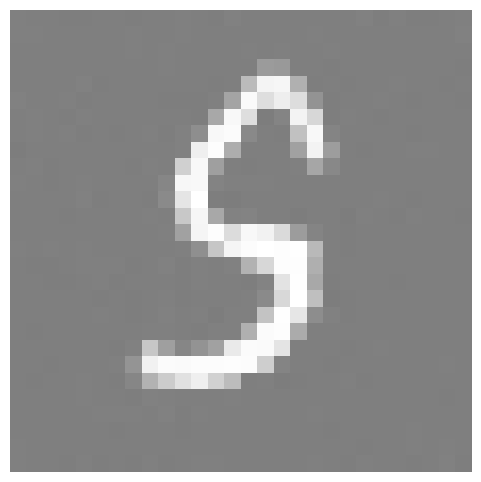

In [ ]:
samples = ddpm.sample((1, 1, 28, 28))
grid = utils.make_grid(samples, nrow=4)
plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.show()

In [ ]:
def save_model_to_npz(model, filename="unet_weights.npz"):
    weights = {}
    for name, param in model.state_dict().items():
        weights[name] = param.cpu().numpy()
    np.savez(filename, **weights)


save_model_to_npz(model)

In [ ]:
# Improved UNet with better time embedding
class UNet(nn.Module):
    def __init__(self, in_channels=2, out_channels=1, timesteps=1000):
        super().__init__()
        self.num_timesteps = timesteps

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),  # Added batch norm
                nn.ReLU(),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU()
            )

        # Improved time embedding
        self.time_embed = nn.Sequential(
            nn.Linear(1, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28)
        )

        self.pool = nn.MaxPool2d(2)

        self.enc1 = conv_block(2, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)

        self.bottleneck = conv_block(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = conv_block(128, 64)

        self.final = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x, t):
        # Normalize timestep and create embedding
        t_normalized = t.float().view(-1, 1) / self.num_timesteps
        t_embed = self.time_embed(t_normalized).view(-1, 1, 28, 28)
        x = torch.cat([x, t_embed], dim=1)

        e1 = self.enc1(x)  # 64 x 28 x 28
        e2 = self.enc2(self.pool(e1))  # 128 x 14 x 14
        e3 = self.enc3(self.pool(e2))  # 256 x 7 x 7

        b = self.bottleneck(self.pool(e3))  # 512 x 3 x 3

        # Handle size mismatches with interpolation
        up3 = self.up3(b)  # 256 x 6 x 6
        up3 = F.interpolate(up3, size=e3.shape[2:], mode='bilinear', align_corners=False)
        d3 = self.dec3(torch.cat([up3, e3], dim=1))

        up2 = self.up2(d3)  # 128 x 14 x 14 (should match e2)
        up2 = F.interpolate(up2, size=e2.shape[2:], mode='bilinear', align_corners=False)
        d2 = self.dec2(torch.cat([up2, e2], dim=1))

        up1 = self.up1(d2)  # 64 x 28 x 28 (should match e1)
        up1 = F.interpolate(up1, size=e1.shape[2:], mode='bilinear', align_corners=False)
        d1 = self.dec1(torch.cat([up1, e1], dim=1))

        return self.final(d1)


# Fixed DDPM class
class DDPM:
    def __init__(self, model, timesteps=1000):
        self.model = model
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)

        self.timesteps = timesteps
        self.betas = cosine_beta_schedule(timesteps).to(self.device)
        self.alphas = 1. - self.betas
        self.alpha_hat = torch.cumprod(self.alphas, dim=0)

        # Precompute constants
        self.sqrt_alpha_hat = torch.sqrt(self.alpha_hat)
        self.sqrt_one_minus_alpha_hat = torch.sqrt(1 - self.alpha_hat)

    def add_noise(self, x0, t, noise):
        return (
            self.sqrt_alpha_hat[t][:, None, None, None] * x0 +
            self.sqrt_one_minus_alpha_hat[t][:, None, None, None] * noise
        )

    def train(self, dataloader, optimizer, epochs=10, use_ema=True):
        if use_ema:
            ema_model = UNet().to(self.device)
            ema_model.load_state_dict(self.model.state_dict())

        def update_ema(ema, model, decay=0.9999):
            for ema_param, param in zip(ema.parameters(), model.parameters()):
                ema_param.data.mul_(decay).add_(param.data, alpha=1 - decay)

        # Add learning rate scheduler
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

        self.model.train()
        for epoch in range(epochs):
            loop = tqdm(dataloader, desc=f"Epoch {epoch+1}")
            epoch_loss = 0

            for batch_idx, (x, _) in enumerate(loop):
                x = x.to(self.device)
                t = torch.randint(0, self.timesteps, (x.size(0),), device=self.device)
                noise = torch.randn_like(x)
                x_noisy = self.add_noise(x, t, noise)

                predicted = self.model(x_noisy, t)
                loss = F.mse_loss(predicted, noise)

                optimizer.zero_grad()
                loss.backward()
                # Add gradient clipping
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                optimizer.step()

                if use_ema:
                    update_ema(ema_model, self.model)

                epoch_loss += loss.item()
                loop.set_postfix(loss=loss.item())

            scheduler.step()
            print(f"Epoch {epoch+1} avg loss: {epoch_loss/len(dataloader):.6f}")

        if use_ema:
            self.model.load_state_dict(ema_model.state_dict())

    @torch.no_grad()
    def sample(self, shape, steps=None):
        steps = steps or self.timesteps
        x = torch.randn(shape).to(self.device)

        self.model.eval()

        for i in range(steps):
            t = steps - i - 1  # Go from steps-1 to 0
            t_batch = torch.full((shape[0],), t, device=self.device, dtype=torch.long)

            if t == 0:
                pred_noise = self.model(x, t_batch)
                # Final step - no noise added
                alpha = self.alphas[t]
                alpha_hat = self.alpha_hat[t]
                x = (1 / alpha.sqrt()) * (x - (1 - alpha) / (1 - alpha_hat).sqrt() * pred_noise)
            else:
                pred_noise = self.model(x, t_batch)
                beta = self.betas[t]
                alpha = self.alphas[t]
                alpha_hat = self.alpha_hat[t]

                x = (1 / alpha.sqrt()) * (x - (1 - alpha) / (1 - alpha_hat).sqrt() * pred_noise)
                noise = torch.randn_like(x)
                x += beta.sqrt() * noise

        # Convert from [-1, 1] to [0, 1]
        return torch.clamp((x + 1) / 2, 0, 1)


# Better training setup
def train_ddpm():
    # Model setup
    model = UNet()
    ddpm = DDPM(model, timesteps=1000)

    # Better optimizer settings
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)

    # Load your dataset
    dataset = CSVMNISTDataset('/content/sample_data/mnist_train_small.csv', has_labels=True)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=4)

    # Train
    ddpm.train(dataloader, optimizer, epochs=50)

    return ddpm

In [ ]:
trained_ddpm = train_ddpm()

In [ ]:
trained_ddpm.sample((1, 1, 28, 28))

In [ ]:
def show_image(matrix):
    """Display a matrix as an image"""
    # Handle tensor on GPU and requires_grad
    if hasattr(matrix, 'detach'):
        matrix = matrix.detach().cpu()
    plt.imshow(matrix.squeeze(), cmap='gray')
    plt.axis('off')
    plt.show()

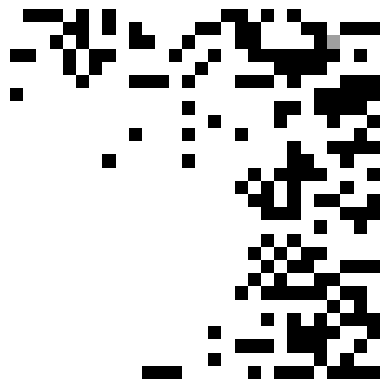

In [ ]:
show_image(trained_ddpm.sample((1,1,28,28)))

### Model verification

In [ ]:
def debug_dataset(dataset, num_samples=8):
    """Check if dataset is loaded correctly"""
    fig, axes = plt.subplots(2, num_samples//2, figsize=(12, 6))
    axes = axes.flatten()

    for i in range(num_samples):
        img, label = dataset[i]
        # Convert from [-1,1] back to [0,1] for display
        img_display = (img + 1) / 2
        axes[i].imshow(img_display.squeeze(), cmap='gray')
        axes[i].set_title(f'Label: {label}')
        axes[i].axis('off')

    plt.suptitle('Dataset Check - Should look like MNIST digits')
    plt.tight_layout()
    plt.show()

def debug_noising_process(ddmp_eval, dataset):
    """Visualize how noise is added to real images"""
    img, _ = dataset[0]  # Get first image
    img = img.unsqueeze(0).to(ddmp_eval.device)  # Add batch dimension

    # Test different noise levels
    timesteps_to_show = [0, 100, 250, 500, 750, 999]

    fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(15, 3))

    for i, t in enumerate(timesteps_to_show):
        t_tensor = torch.tensor([t]).to(ddmp_eval.device)
        noise = torch.randn_like(img)
        noisy_img = ddmp_eval.add_noise(img, t_tensor, noise)

        # Convert back to [0,1] for display
        display_img = (noisy_img + 1) / 2
        display_img = torch.clamp(display_img, 0, 1)

        axes[i].imshow(display_img.cpu().squeeze(), cmap='gray')
        axes[i].set_title(f't={t}')
        axes[i].axis('off')

    plt.suptitle('Noise Addition Process (should go from digit to noise)')
    plt.tight_layout()
    plt.show()

def check_model_predictions(ddmp_eval, dataset):
    """Check if model can predict noise correctly"""
    img, _ = dataset[0]
    img = img.unsqueeze(0).to(ddmp_eval.device)

    # Add noise at different levels and see model predictions
    timesteps_to_test = [100, 500, 900]

    fig, axes = plt.subplots(3, len(timesteps_to_test), figsize=(12, 9))

    ddmp_eval.model.eval()
    with torch.no_grad():
        for i, t in enumerate(timesteps_to_test):
            t_tensor = torch.tensor([t]).to(ddmp_eval.device)
            true_noise = torch.randn_like(img)
            noisy_img = ddmp_eval.add_noise(img, t_tensor, true_noise)

            # Model prediction
            pred_noise = ddmp_eval.model(noisy_img, t_tensor)

            # Display noisy image
            display_noisy = (noisy_img + 1) / 2
            axes[0, i].imshow(display_noisy.cpu().squeeze(), cmap='gray')
            axes[0, i].set_title(f'Noisy Image t={t}')
            axes[0, i].axis('off')

            # Display true noise
            display_true = (true_noise + 1) / 2
            axes[1, i].imshow(display_true.cpu().squeeze(), cmap='gray')
            axes[1, i].set_title('True Noise')
            axes[1, i].axis('off')

            # Display predicted noise
            display_pred = (pred_noise + 1) / 2
            axes[2, i].imshow(display_pred.cpu().squeeze(), cmap='gray')
            axes[2, i].set_title('Predicted Noise')
            axes[2, i].axis('off')

    plt.suptitle('Model Noise Prediction (pred should match true)')
    plt.tight_layout()
    plt.show()

def check_training_loss(ddpm, dataloader):
    """Quick training loss check"""
    ddpm.model.eval()
    total_loss = 0
    num_batches = 0

    with torch.no_grad():
        for x, _ in dataloader:
            if num_batches >= 10:  # Just check first 10 batches
                break
            x = x.to(ddpm.device)
            t = torch.randint(0, ddpm.timesteps, (x.size(0),), device=ddpm.device)
            noise = torch.randn_like(x)
            x_noisy = ddpm.add_noise(x, t, noise)

            predicted = ddpm.model(x_noisy, t)
            loss = torch.nn.functional.mse_loss(predicted, noise)
            total_loss += loss.item()
            num_batches += 1

    avg_loss = total_loss / num_batches
    print(f"Current average loss: {avg_loss:.6f}")
    print("Good loss should be < 0.1, bad loss > 1.0")

    return avg_loss

# Main debug function
def full_debug(ddpm, dataset, dataloader):
    """Run all debug checks"""
    print("=== DEBUGGING DDPM ===")

    print("\n1. Checking dataset...")
    debug_dataset(dataset)

    print("\n2. Checking noise addition...")
    debug_noising_process(ddpm, dataset)

    print("\n3. Checking model predictions...")
    check_model_predictions(ddpm, dataset)

    print("\n4. Checking training loss...")
    loss = check_training_loss(ddpm, dataloader)

    if loss > 1.0:
        print("❌ HIGH LOSS - Model not trained properly!")
    elif loss > 0.1:
        print("⚠️  MEDIUM LOSS - Model needs more training")
    else:
        print("✅ LOW LOSS - Model seems trained")

    return loss

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


=== DEBUGGING DDPM ===

1. Checking dataset...


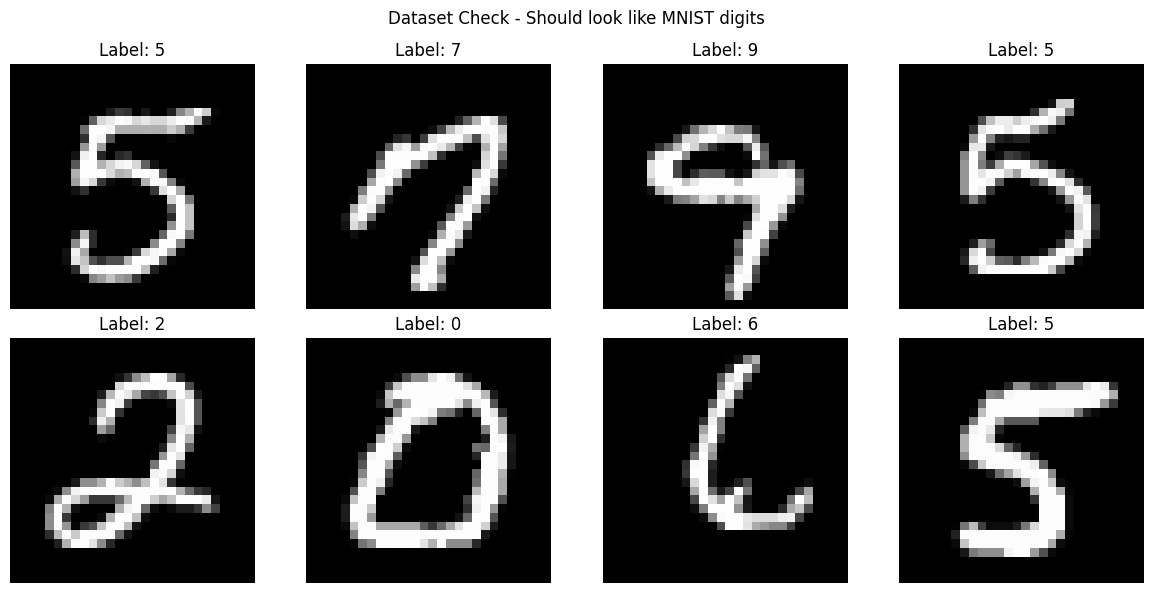


2. Checking noise addition...


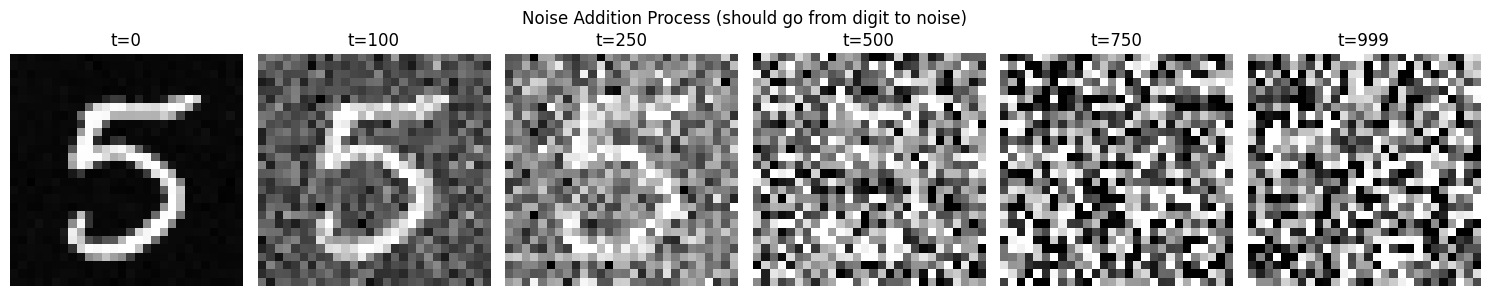


3. Checking model predictions...


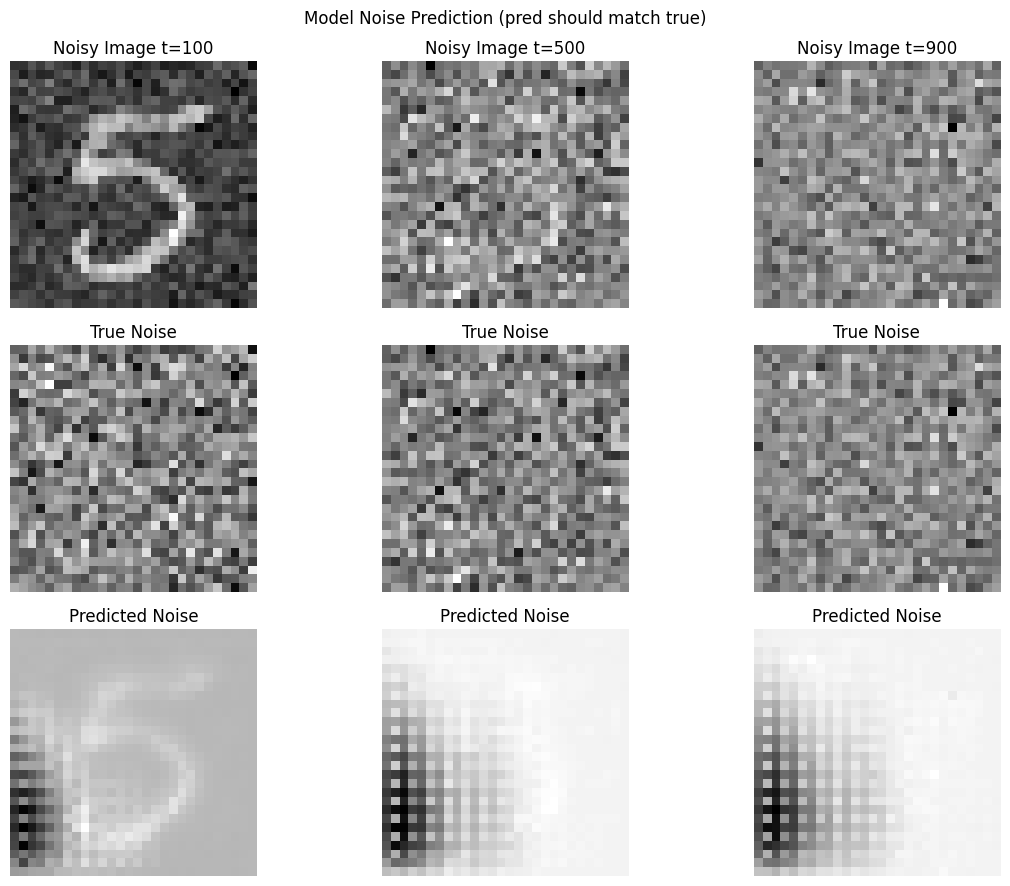


4. Checking training loss...
Current average loss: 1.025684
Good loss should be < 0.1, bad loss > 1.0
❌ HIGH LOSS - Model not trained properly!


1.0256835222244263

In [ ]:
dataset = CSVMNISTDataset('/content/sample_data/mnist_train_small.csv', has_labels=True)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=4)
full_debug(trained_ddpm, dataset, dataloader)

### Visualization

In [ ]:
# Fix the sampling method without retraining
def fixed_sample(self, shape, steps=None):
    steps = steps or self.timesteps
    x = torch.randn(shape).to(self.device)

    self.model.eval()

    for i in range(steps):
        t = steps - i - 1  # Go from steps-1 to 0
        t_batch = torch.full((shape[0],), t, device=self.device, dtype=torch.long)

        pred_noise = self.model(x, t_batch)

        beta = self.betas[t]
        alpha = self.alphas[t]
        alpha_hat = self.alpha_hat[t]

        # DDPM sampling formula
        x = (1 / alpha.sqrt()) * (x - (1 - alpha) / (1 - alpha_hat).sqrt() * pred_noise)

        if t > 0:
            noise = torch.randn_like(x)
            x += beta.sqrt() * noise

    # Convert from [-1, 1] to [0, 1]
    return torch.clamp((x + 1) / 2, 0, 1)

# Replace the method on your existing trained model
trained_ddpm.sample = fixed_sample.__get__(trained_ddpm, DDPM)

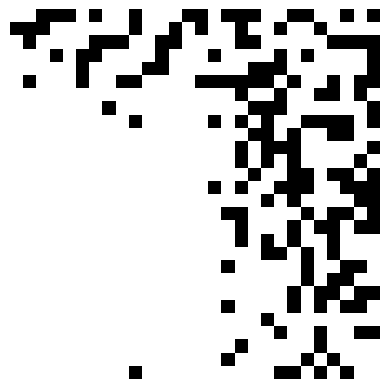

In [ ]:
sample = trained_ddpm.sample((1, 1, 28, 28))
show_image(sample)